<a href="https://colab.research.google.com/github/davidlealo/practicos_sisrec_2026/blob/main/practico02/02_pyRecLab_FunkSVD_RESPUESTADLO.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Repo

Estoy subiendo mis respuestas también a [Repo en GitHub](https://github.com/davidlealo/practicos_sisrec_2026/blob/main/practico02/02_pyRecLab_FunkSVD_RESPUESTADLO.ipynb)

# Práctica de Sistemas Recomendadores: pyreclab - Funk's SVD

En este práctico implementaremos un recomendador basado en un algoritmo de factorización matricial propuesto por [Simon Funk](https://sifter.org/simon/journal/20061211.html).

Volveremos a utilizar la biblioteca de Python [pyreclab](https://github.com/gasevi/pyreclab), desarrollado por los Laboratorios IALab y SocVis de la Pontificia Universidad Católica de Chile.

**Adaptado por**: Vladimir Araujo

**Material original de**: Denis Parra, Gabriel Sepúlveda, Antonio Ossa, Manuel Cartagena


## Configuración inicial

In [1]:
!pip install gdown

**Paso 1:** Descargue directamente a Colab los archivos del dataset ejecutando las siguientes 3 celdas:

In [2]:
!gdown 15Y164QnWdmus9QBHWBCwyYezMACZsx-h

Downloading...
From: https://drive.google.com/uc?id=15Y164QnWdmus9QBHWBCwyYezMACZsx-h
To: /content/u2.base
100% 1.58M/1.58M [00:00<00:00, 14.5MB/s]


In [3]:
!gdown 1lSlGE1daKvGqg6-nUcMzT9lJK66HPZEJ

Downloading...
From: https://drive.google.com/uc?id=1lSlGE1daKvGqg6-nUcMzT9lJK66HPZEJ
To: /content/u2.test
100% 395k/395k [00:00<00:00, 14.5MB/s]


In [4]:
!gdown 13afMOhZGgIKLz784biKbvZ1rnM4iJzLk

Downloading...
From: https://drive.google.com/uc?id=13afMOhZGgIKLz784biKbvZ1rnM4iJzLk
To: /content/u.item
100% 236k/236k [00:00<00:00, 7.52MB/s]


**Paso 2**: Instalamos [`pyreclab`](https://github.com/gasevi/pyreclab) y [`seaborn`](https://seaborn.pydata.org/index.html) utilizando `pip`.

In [5]:
!pip install pyreclab --upgrade
#!pip install seaborn --upgrade

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 225.0/225.0 kB 7.7 MB/s eta 0:00:00


In [6]:
import pandas as pd
import pyreclab
import seaborn as sns
import numpy as np
import scipy.sparse as sparse
import matplotlib.pyplot as plt

%matplotlib inline
sns.set(style="whitegrid")

## Antes de recomendar

**Paso 3**: Los archivos `u2.base` y `u2.test` tienen tuplas (usuario, item, rating, timestamp), que es la información de preferencias de usuarios sobre películas en una muestra del dataset [MovieLens](https://grouplens.org/datasets/movielens/). Revisemos cómo es uno de estos archivos y luego haremos gráficos que nos permitan sacar conclusiones a partir del mismo.

In [7]:
# Primero creamos el dataframe con los datos
df_train = pd.read_csv('u2.base',
                         sep='\t',
                         names=['userid', 'itemid', 'rating', 'timestamp'],
                         header=None)
df_train.head()

,userid,itemid,rating,timestamp
0,1,3,4,878542960
1,1,4,3,876893119
2,1,5,3,889751712
3,1,6,5,887431973
4,1,7,4,875071561


In [8]:
# Ahora queremos realizar una observación rápida de los datos
df_train.describe()

,userid,itemid,rating,timestamp
count,80000.000000,80000.000000,80000.000000,8.000000e+04
mean,494.508137,424.990487,3.526463,8.835467e+08
std,276.879511,330.564093,1.124429,5.379549e+06
min,1.000000,1.000000,1.000000,8.747247e+08
25%,269.000000,174.000000,3.000000,8.794471e+08
50%,500.000000,321.000000,4.000000,8.828278e+08
75%,744.000000,630.000000,4.000000,8.884652e+08
max,943.000000,1682.000000,5.000000,8.932866e+08


Por otra parte, para obtener información adicional de cada película tal como **título**, **fecha de lanzamiento**, **género**, etc., cargaremos el archivo de items descargado (`u.item`) para poder mapear cada identificador de ítem al conjunto de datos que lo describe. Revisemos el contenido de este archivo

In [9]:
columns = ['movieid', 'title', 'release_date', 'video_release_date', \
           'IMDb_URL', 'unknown', 'Action', 'Adventure', 'Animation', \
           'Children', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Fantasy', \
           'Film-Noir', 'Horror', 'Musical', 'Mystery', 'Romance', 'Sci-Fi', \
           'Thriller', 'War', 'Western']

In [10]:
# Cargamos el dataset con los items
df_items = pd.read_csv('u.item',
                        sep='|',
                        index_col=0,
                        names = columns,
                        header=None,
                        encoding='latin-1')
df_items.head()

,title,release_date,video_release_date,IMDb_URL,unknown,Action,Adventure,Animation,Children,Comedy,...,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
movieid,,,,,,,,,,,,,,,,,,,,,
1,Toy Story (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Toy%20Story%2...,0,0,0,1,1,1,...,0,0,0,0,0,0,0,0,0,0
2,GoldenEye (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?GoldenEye%20(...,0,1,1,0,0,0,...,0,0,0,0,0,0,0,1,0,0
3,Four Rooms (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Four%20Rooms%...,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
4,Get Shorty (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Get%20Shorty%...,0,1,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
5,Copycat (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Copycat%20(1995),0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0


In [11]:
# Realizamos una inspección sobre estos datos (.info())
df_items.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1682 entries, 1 to 1682
Data columns (total 23 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   title               1682 non-null   object 
 1   release_date        1681 non-null   object 
 2   video_release_date  0 non-null      float64
 3   IMDb_URL            1679 non-null   object 
 4   unknown             1682 non-null   int64  
 5   Action              1682 non-null   int64  
 6   Adventure           1682 non-null   int64  
 7   Animation           1682 non-null   int64  
 8   Children            1682 non-null   int64  
 9   Comedy              1682 non-null   int64  
 10  Crime               1682 non-null   int64  
 11  Documentary         1682 non-null   int64  
 12  Drama               1682 non-null   int64  
 13  Fantasy             1682 non-null   int64  
 14  Film-Noir           1682 non-null   int64  
 15  Horror              1682 non-null   int64  
 16  Musical    

In [12]:
# Ejemplo de cómo visualizar titulos de peliculas en base a sus IDs
pelis = [5,4,1]
df_items.loc[pelis]['title']

,title
movieid,
5,Copycat (1995)
4,Get Shorty (1995)
1,Toy Story (1995)


**Paso 4:** Generemos algunos gráficos en relación a las películas.

/tmp/ipykernel_38330/1823837166.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=genre_count.values, y=genre_count.index, label="Total", palette="Blues_d")


<Axes: ylabel='None'>

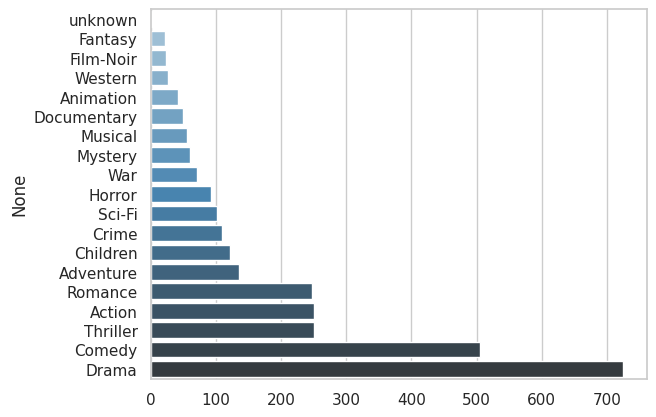

In [13]:
#Ignorar el warning
genre_columns = ['unknown', 'Action', 'Adventure', 'Animation', \
           'Children', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Fantasy', \
           'Film-Noir', 'Horror', 'Musical', 'Mystery', 'Romance', 'Sci-Fi', \
           'Thriller', 'War', 'Western']

genre_count = df_items[genre_columns].sum().sort_values()

sns.barplot(x=genre_count.values, y=genre_count.index, label="Total", palette="Blues_d")

**Paso 5 (2ptos):** Explique cómo funciona SVD (como modelo, no piense en la implementación).





**Respuesta:** *COMPLETAR*

El SVD es una técnica para reducir las dimensionalidades de una matriz en el espacio latente. Con esto podemos representar con una menor cantidad de dimensiones, las cuales no son interpretables directamente, las cuales tienen la capacidad de explicar todas las variables, reduciendo el problema de cómputo y la maldición de la dimensionalidad.

En el párrafo anterior hablé del espacio latente y SVD no es la única técnica (recuerdo que antes usé PCA por ejemplo), pero ahora qué es SVD. Esta técnica lo que hace es factorizar la matriz de usuario-ítem con la que trabajamos comúnmente en tres:

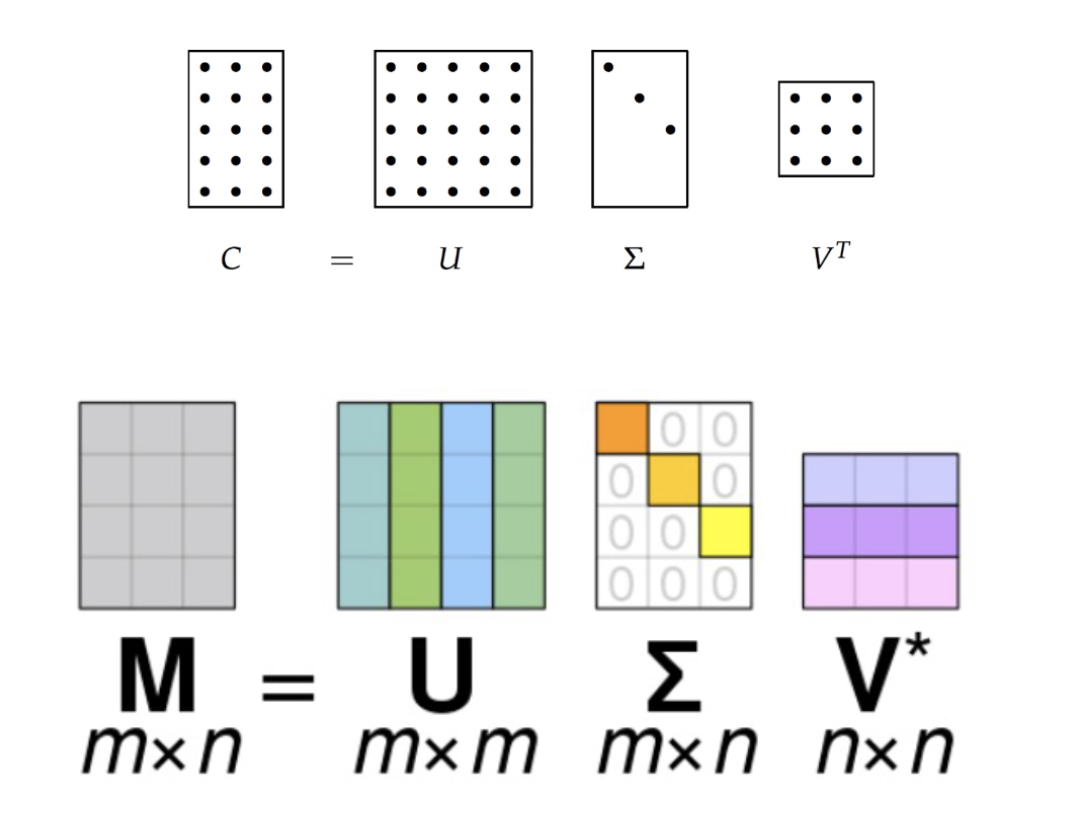 FOTO de [imagen](https://github.com/davidlealo/recsyspuc-2026-1/blob/master/clases/s2_c2-Factorizacion_matricial_v2025.pdf)

Esta matriz la podemos manipular para obtener una representación de bajo ranking (A').

**¿Cómo funciona el modelo?** Encuentra los valores en el espacio latente que representa la información, bajando las dimensionalidades. Aunque no es interpretable directamente si mantiene las características, o por lo menos la mayoría de ellas, para después hacer una reconstrucción.

Al simplificar las dimensiones, porque podemos reducir las dimensionalidades como se explicaba en un inicio nos permite reducir la cantidad de cómputo necesario, eliminando el ruido y luego se puede reconstruir la matriz original.

**Usé IA?** En este caso no, pero hice el curso que estaba en el repo de recsyspuc-2026-1 y la respuesta está muy interpretada de este video [video](https://www.coursera.org/learn/fundamentos-de-sistemas-recomendadores/lecture/1xAYs/factorizacion-matricial-para-predecir-factores-latentes)

## SVD

**Paso 6**: Tome un usuario, cualquiera, del dataset y reporte parte de sus gustos explícitamente (es decir, nombre de las películas, género, etc., no id). Para este mismo usuario, revise explícitamente las recomendaciones al llegar a la parametrización que reporta las mejores métricas.

In [14]:
user_id = 2
user_df = df_train[df_train['userid'] == user_id]

df_items.loc[user_df['itemid'].values]

,title,release_date,video_release_date,IMDb_URL,unknown,Action,Adventure,Animation,Children,Comedy,...,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
movieid,,,,,,,,,,,,,,,,,,,,,
13,Mighty Aphrodite (1995),30-Oct-1995,NaN,http://us.imdb.com/M/title-exact?Mighty%20Aphr...,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
19,Antonia's Line (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Antonia%20(1995),0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
50,Star Wars (1977),01-Jan-1977,NaN,http://us.imdb.com/M/title-exact?Star%20Wars%2...,0,1,1,0,0,0,...,0,0,0,0,0,1,1,0,1,0
100,Fargo (1996),14-Feb-1997,NaN,http://us.imdb.com/M/title-exact?Fargo%20(1996),0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
127,"Godfather, The (1972)",01-Jan-1972,NaN,"http://us.imdb.com/M/title-exact?Godfather,%20...",0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
237,Jerry Maguire (1996),13-Dec-1996,NaN,http://us.imdb.com/M/title-exact?Jerry%20Magui...,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
251,Shall We Dance? (1996),11-Jul-1997,NaN,http://us.imdb.com/M/title-exact?Shall%20we%20...,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
255,My Best Friend's Wedding (1997),20-Jun-1997,NaN,http://us.imdb.com/M/title-exact?My+Best+Frien...,0,0,0,0,0,1,...,0,0,0,0,0,1,0,0,0,0
257,Men in Black (1997),04-Jul-1997,NaN,http://us.imdb.com/M/title-exact?Men+in+Black+...,0,1,1,0,0,1,...,0,0,0,0,0,0,1,0,0,0


In [15]:
# Definicion de objeto svd
svd = pyreclab.SVD(dataset='u2.base',
                   dlmchar=b'\t',
                   header=False,
                   usercol=0,
                   itemcol=1,
                   ratingcol=2)

# Entrenamiento del modelo
svd.train(factors=100, maxiter=100, lr=0.01, lamb=0.1)

In [16]:
# Testing de predicciones
predlist, mae, rmse = svd.test(input_file='u2.test',
                               dlmchar=b'\t',
                               header=False,
                               usercol=0,
                               itemcol=1,
                               ratingcol=2)

print('MAE: {}\nRMSE: {}'.format(mae, rmse))

MAE: 0.7204385735275243
RMSE: 0.9144358027682138


In [17]:
# Testing de recomendaciones
top_n = 20

recommendList, maprec, ndcg = svd.testrec(input_file='u2.test',
                                          dlmchar=b'\t',
                                          header=False,
                                          usercol=0,
                                          itemcol=1,
                                          ratingcol=2,
                                          topn=top_n,
                                          relevance_threshold=2,
                                          includeRated=False)

print('MAP: {}\nNDCG@{}: {}'.format(maprec, top_n, ndcg))

MAP: 0.11509592320081265
NDCG@20: 0.06261441575617019


In [18]:
# Calcular las recomendaciones para el usuario escogido
ranking = [int(r) for r in svd.recommend(str(user_id), top_n, includeRated=False)]
print('Recommendation for user {}: {}'.format(user_id, ranking))

Recommendation for user 2: [1512, 1449, 169, 1398, 1367, 1500, 483, 1558, 408, 318, 480, 64, 134, 1642, 963, 174, 114, 172, 320, 189]


In [19]:
# Ver explicitamente las recomendaciones para un usuario
df_items.loc[ranking]

,title,release_date,video_release_date,IMDb_URL,unknown,Action,Adventure,Animation,Children,Comedy,...,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
movieid,,,,,,,,,,,,,,,,,,,,,
1512,"World of Apu, The (Apur Sansar) (1959)",05-Apr-1996,NaN,http://us.imdb.com/M/title-exact?Apur%20Sansar...,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1449,Pather Panchali (1955),22-Mar-1996,NaN,http://us.imdb.com/M/title-exact?Pather%20Panc...,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
169,"Wrong Trousers, The (1993)",01-Jan-1993,NaN,http://us.imdb.com/M/title-exact?Wrong%20Trous...,0,0,0,1,0,1,...,0,0,0,0,0,0,0,0,0,0
1398,Anna (1996),13-Nov-1996,NaN,http://us.imdb.com/M/title-exact?Anna%20(1996),0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1367,Faust (1994),01-Jan-1994,NaN,http://us.imdb.com/M/title-exact?Faust%20%2819...,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
1500,Santa with Muscles (1996),08-Nov-1996,NaN,http://us.imdb.com/M/title-exact?Santa%20with%...,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
483,Casablanca (1942),01-Jan-1942,NaN,http://us.imdb.com/M/title-exact?Casablanca%20...,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,1,0
1558,Aparajito (1956),29-Mar-1996,NaN,http://us.imdb.com/M/title-exact?Aparajito%20(...,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
408,"Close Shave, A (1995)",28-Apr-1996,NaN,http://us.imdb.com/M/title-exact?Close%20Shave...,0,0,0,1,0,1,...,0,0,0,0,0,0,0,1,0,0


**Paso 7 (10ptos):** Pruebe distintos valores de los parámetros de entrenamiento del algoritmo SVD:
- Número de factores (n_factors)
- Número de iteraciones máxima (n_epochs)
- Learning rate (lr_all)

Y hay muchos más que pueden probar.

Describa cómo estos afectan las métricas y las recomendaciones hechas para el usuario que escogió (2 ptos por cada combinación probada y comentada): *COMPLETAR*

In [20]:
# Voy a probar cambiando la cantidad de factores

factores = [100, 150, 200, 250, 300, 350, 400, 450, 500]

# Definicion de objeto svd
svd = pyreclab.SVD(dataset='u2.base',
                   dlmchar=b'\t',
                   header=False,
                   usercol=0,
                   itemcol=1,
                   ratingcol=2)

# Modelo con los distintos factores
for f in factores:
  svd.train(factors=f, maxiter=100, lr=0.01, lamb=0.1)
  # Testing de predicciones
  predlist, mae, rmse = svd.test(input_file='u2.test',
                               dlmchar=b'\t',
                               header=False,
                               usercol=0,
                               itemcol=1,
                               ratingcol=2)

  print('Número de factores: {}\nMAE: {}\nRMSE: {}'.format(f, mae, rmse))


Número de factores: 100
MAE: 0.7213743281774728
RMSE: 0.9154444528219665
Número de factores: 150
MAE: 0.7204942779768736
RMSE: 0.9139589964735328
Número de factores: 200
MAE: 0.7202827475607512
RMSE: 0.9137803248819522
Número de factores: 250
MAE: 0.7203252344207467
RMSE: 0.9132532754149746
Número de factores: 300
MAE: 0.7198168822820685
RMSE: 0.9128166268789054
Número de factores: 350
MAE: 0.7200247386792126
RMSE: 0.9130596219375843
Número de factores: 400
MAE: 0.7204694509978428
RMSE: 0.9134771567376098
Número de factores: 450
MAE: 0.7199446930606602
RMSE: 0.9130805313624031
Número de factores: 500
MAE: 0.7203171501876625
RMSE: 0.9133076447922392


In [21]:
# Voy a probar cambiando la cantidad de iteraciones

interacciones = [100, 150, 200, 250, 300, 350, 400, 450, 500]

# Definicion de objeto svd
svd = pyreclab.SVD(dataset='u2.base',
                   dlmchar=b'\t',
                   header=False,
                   usercol=0,
                   itemcol=1,
                   ratingcol=2)

# Modelo con los distintos interacciones
for i in interacciones:
  svd.train(factors=100, maxiter=i, lr=0.01, lamb=0.1)
  # Testing de predicciones
  predlist, mae, rmse = svd.test(input_file='u2.test',
                               dlmchar=b'\t',
                               header=False,
                               usercol=0,
                               itemcol=1,
                               ratingcol=2)

  print('Número de interacciones: {}\nMAE: {}\nRMSE: {}'.format(i, mae, rmse))


Número de interacciones: 100
MAE: 0.7207200258970083
RMSE: 0.9144238515606922
Número de interacciones: 150
MAE: 0.7209690644628933
RMSE: 0.9148743399793297
Número de interacciones: 200
MAE: 0.7215182430472755
RMSE: 0.9156892120493053
Número de interacciones: 250
MAE: 0.7215971849222843
RMSE: 0.9157649579090511
Número de interacciones: 300
MAE: 0.7218071785817842
RMSE: 0.9159954742442044
Número de interacciones: 350
MAE: 0.721547297112263
RMSE: 0.9157009736929791
Número de interacciones: 400
MAE: 0.7214615114390992
RMSE: 0.9156444081694729
Número de interacciones: 450
MAE: 0.7216406119620671
RMSE: 0.9158383597764584
Número de interacciones: 500
MAE: 0.7217244615150504
RMSE: 0.915745968031284


In [22]:
# Voy a probar cambiando el learning_rate

learning_rate = [0.01, 0.02, 0.03, 0.04, 0.05]

# Definicion de objeto svd
svd = pyreclab.SVD(dataset='u2.base',
                   dlmchar=b'\t',
                   header=False,
                   usercol=0,
                   itemcol=1,
                   ratingcol=2)

# Modelo con los distintos interacciones
for l in learning_rate:
  svd.train(factors=100, maxiter=100, lr=l, lamb=0.1)
  # Testing de predicciones
  predlist, mae, rmse = svd.test(input_file='u2.test',
                               dlmchar=b'\t',
                               header=False,
                               usercol=0,
                               itemcol=1,
                               ratingcol=2)

  print('Learning Rate: {}\nMAE: {}\nRMSE: {}'.format(l, mae, rmse))


Learning Rate: 0.01
MAE: 0.7213141982139747
RMSE: 0.9153596705021555
Learning Rate: 0.02
MAE: 0.7246712223267135
RMSE: 0.9183224095825094
Learning Rate: 0.03
MAE: 0.7285921260973964
RMSE: 0.9223029006158027
Learning Rate: 0.04
MAE: 0.7332111142181664
RMSE: 0.9270389864391335
Learning Rate: 0.05
MAE: 0.737936214700887
RMSE: 0.9319466276431054


In [36]:
user_id = 5
user_df = df_train[df_train['userid'] == user_id]

df_items.loc[user_df['itemid'].values]

,title,release_date,video_release_date,IMDb_URL,unknown,Action,Adventure,Animation,Children,Comedy,...,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
movieid,,,,,,,,,,,,,,,,,,,,,
1,Toy Story (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Toy%20Story%2...,0,0,0,1,1,1,...,0,0,0,0,0,0,0,0,0,0
2,GoldenEye (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?GoldenEye%20(...,0,1,1,0,0,0,...,0,0,0,0,0,0,0,1,0,0
17,From Dusk Till Dawn (1996),05-Feb-1996,NaN,http://us.imdb.com/M/title-exact?From%20Dusk%2...,0,1,0,0,0,1,...,0,0,1,0,0,0,0,1,0,0
24,Rumble in the Bronx (1995),23-Feb-1996,NaN,http://us.imdb.com/M/title-exact?Hong%20Faan%2...,0,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
40,"To Wong Foo, Thanks for Everything! Julie Newm...",01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?To%20Wong%20F...,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
450,Star Trek V: The Final Frontier (1989),01-Jan-1989,NaN,http://us.imdb.com/M/title-exact?Star%20Trek%2...,0,1,1,0,0,0,...,0,0,0,0,0,0,1,0,0,0
453,Jaws 3-D (1983),01-Jan-1983,NaN,http://us.imdb.com/M/title-exact?Jaws%203-D%20...,0,1,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
454,Bastard Out of Carolina (1996),15-Dec-1996,NaN,http://us.imdb.com/M/title-exact?Bastard%20Out...,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [37]:
# Cambios por top 3 de los ejercicios anteriores
cambios = {
    "factores": [300, 350, 450],
    "interacciones": [100, 150, 400],
    "learning_rate": [0.01, 0.02, 0.03]
}

top_n = 3

# Modelo con los distintos interacciones
for f, it, lr in zip(cambios["factores"], cambios["interacciones"], cambios["learning_rate"]):


    svd = pyreclab.SVD(dataset='u2.base', dlmchar=b'\t', header=False, usercol=0, itemcol=1, ratingcol=2)
    svd.train(factors=f, maxiter=it, lr=lr, lamb=0.1)


    predlist, mae, rmse = svd.test(input_file='u2.test', dlmchar=b'\t', header=False, usercol=0, itemcol=1, ratingcol=2)


    recommendList, maprec, ndcg = svd.testrec(input_file='u2.test', dlmchar=b'\t', header=False,
                                             usercol=0, itemcol=1, ratingcol=2,
                                             topn=top_n, relevance_threshold=2, includeRated=False)


    ranking = [int(r) for r in svd.recommend(str(user_id), top_n, includeRated=False)]


    print(f"--- CONFIG: Factores={f}, Iteraciones={it}, LR={lr} ---")
    print(f"MAE: {mae:.4f} | RMSE: {rmse:.4f}")
    print(f"MAP: {maprec:.4f} | NDCG@{top_n}: {ndcg:.4f}")
    print(f"Películas sugeridas para el usuario {user_id}:")

    # Mostrar los tres títulos principales
    display(df_items.loc[ranking][['title']])
    print("\n" + "="*50 + "\n")

--- CONFIG: Factores=300, Iteraciones=100, LR=0.01 ---
MAE: 0.7204 | RMSE: 0.9131
MAP: 0.1078 | NDCG@3: 0.0661
Películas sugeridas para el usuario 5:


,title
movieid,
408,"Close Shave, A (1995)"
114,Wallace & Gromit: The Best of Aardman Animatio...
285,Secrets & Lies (1996)




--- CONFIG: Factores=350, Iteraciones=150, LR=0.02 ---
MAE: 0.7241 | RMSE: 0.9175
MAP: 0.1089 | NDCG@3: 0.0660
Películas sugeridas para el usuario 5:


,title
movieid,
408,"Close Shave, A (1995)"
285,Secrets & Lies (1996)
114,Wallace & Gromit: The Best of Aardman Animatio...




--- CONFIG: Factores=450, Iteraciones=400, LR=0.03 ---
MAE: 0.7287 | RMSE: 0.9224
MAP: 0.1018 | NDCG@3: 0.0645
Películas sugeridas para el usuario 5:


,title
movieid,
408,"Close Shave, A (1995)"
285,Secrets & Lies (1996)
114,Wallace & Gromit: The Best of Aardman Animatio...


In [38]:
# Cambios por top 1 de los ejercicios anteriores
cambios = {
    "factores": [300],
    "interacciones": [100],
    "learning_rate": [0.01]
}

top_n = 3

# Modelo con los distintos interacciones
for f, it, lr in zip(cambios["factores"], cambios["interacciones"], cambios["learning_rate"]):


    svd = pyreclab.SVD(dataset='u2.base', dlmchar=b'\t', header=False, usercol=0, itemcol=1, ratingcol=2)
    svd.train(factors=f, maxiter=it, lr=lr, lamb=0.1)


    predlist, mae, rmse = svd.test(input_file='u2.test', dlmchar=b'\t', header=False, usercol=0, itemcol=1, ratingcol=2)


    recommendList, maprec, ndcg = svd.testrec(input_file='u2.test', dlmchar=b'\t', header=False,
                                             usercol=0, itemcol=1, ratingcol=2,
                                             topn=top_n, relevance_threshold=2, includeRated=False)


    ranking = [int(r) for r in svd.recommend(str(user_id), top_n, includeRated=False)]


    print(f"--- CONFIG: Factores={f}, Iteraciones={it}, LR={lr} ---")
    print(f"MAE: {mae:.4f} | RMSE: {rmse:.4f}")
    print(f"MAP: {maprec:.4f} | NDCG@{top_n}: {ndcg:.4f}")
    print(f"Películas sugeridas para el usuario {user_id}:")

    # Mostrar los tres títulos principales
    display(df_items.loc[ranking][['title']])
    print("\n" + "="*50 + "\n")

--- CONFIG: Factores=300, Iteraciones=100, LR=0.01 ---
MAE: 0.7203 | RMSE: 0.9136
MAP: 0.1163 | NDCG@3: 0.0729
Películas sugeridas para el usuario 5:


,title
movieid,
408,"Close Shave, A (1995)"
285,Secrets & Lies (1996)
114,Wallace & Gromit: The Best of Aardman Animatio...


In [39]:
# Cambios por top 1 de los ejercicios anteriores
cambios = {
    "factores": [300],
    "interacciones": [100],
    "learning_rate": [0.01]
}

top_n = 5

# Modelo con los distintos interacciones
for f, it, lr in zip(cambios["factores"], cambios["interacciones"], cambios["learning_rate"]):


    svd = pyreclab.SVD(dataset='u2.base', dlmchar=b'\t', header=False, usercol=0, itemcol=1, ratingcol=2)
    svd.train(factors=f, maxiter=it, lr=lr, lamb=0.1)


    predlist, mae, rmse = svd.test(input_file='u2.test', dlmchar=b'\t', header=False, usercol=0, itemcol=1, ratingcol=2)


    recommendList, maprec, ndcg = svd.testrec(input_file='u2.test', dlmchar=b'\t', header=False,
                                             usercol=0, itemcol=1, ratingcol=2,
                                             topn=top_n, relevance_threshold=2, includeRated=False)


    ranking = [int(r) for r in svd.recommend(str(user_id), top_n, includeRated=False)]


    print(f"--- CONFIG: Factores={f}, Iteraciones={it}, LR={lr} ---")
    print(f"MAE: {mae:.4f} | RMSE: {rmse:.4f}")
    print(f"MAP: {maprec:.4f} | NDCG@{top_n}: {ndcg:.4f}")
    print(f"Películas sugeridas para el usuario {user_id}:")

    # Mostrar los tres títulos principales
    display(df_items.loc[ranking][['title']])
    print("\n" + "="*50 + "\n")

--- CONFIG: Factores=300, Iteraciones=100, LR=0.01 ---
MAE: 0.7200 | RMSE: 0.9133
MAP: 0.1415 | NDCG@5: 0.0756
Películas sugeridas para el usuario 5:


,title
movieid,
408,"Close Shave, A (1995)"
114,Wallace & Gromit: The Best of Aardman Animatio...
285,Secrets & Lies (1996)
50,Star Wars (1977)
1398,Anna (1996)


In [40]:
# Cambios por top 2 de los ejercicios anteriores
cambios = {
    "factores": [350],
    "interacciones": [150],
    "learning_rate": [0.02]
}

top_n = 5

# Modelo con los distintos interacciones
for f, it, lr in zip(cambios["factores"], cambios["interacciones"], cambios["learning_rate"]):


    svd = pyreclab.SVD(dataset='u2.base', dlmchar=b'\t', header=False, usercol=0, itemcol=1, ratingcol=2)
    svd.train(factors=f, maxiter=it, lr=lr, lamb=0.1)


    predlist, mae, rmse = svd.test(input_file='u2.test', dlmchar=b'\t', header=False, usercol=0, itemcol=1, ratingcol=2)


    recommendList, maprec, ndcg = svd.testrec(input_file='u2.test', dlmchar=b'\t', header=False,
                                             usercol=0, itemcol=1, ratingcol=2,
                                             topn=top_n, relevance_threshold=2, includeRated=False)


    ranking = [int(r) for r in svd.recommend(str(user_id), top_n, includeRated=False)]


    print(f"--- CONFIG: Factores={f}, Iteraciones={it}, LR={lr} ---")
    print(f"MAE: {mae:.4f} | RMSE: {rmse:.4f}")
    print(f"MAP: {maprec:.4f} | NDCG@{top_n}: {ndcg:.4f}")
    print(f"Películas sugeridas para el usuario {user_id}:")

    # Mostrar los tres títulos principales
    display(df_items.loc[ranking][['title']])
    print("\n" + "="*50 + "\n")

--- CONFIG: Factores=350, Iteraciones=150, LR=0.02 ---
MAE: 0.7242 | RMSE: 0.9177
MAP: 0.1270 | NDCG@5: 0.0673
Películas sugeridas para el usuario 5:


,title
movieid,
408,"Close Shave, A (1995)"
114,Wallace & Gromit: The Best of Aardman Animatio...
285,Secrets & Lies (1996)
647,Ran (1985)
50,Star Wars (1977)


In [41]:
# Cambios por top 3 de los ejercicios anteriores
cambios = {
    "factores": [450],
    "interacciones": [400],
    "learning_rate": [0.03]
}

top_n = 5

# Modelo con los distintos interacciones
for f, it, lr in zip(cambios["factores"], cambios["interacciones"], cambios["learning_rate"]):


    svd = pyreclab.SVD(dataset='u2.base', dlmchar=b'\t', header=False, usercol=0, itemcol=1, ratingcol=2)
    svd.train(factors=f, maxiter=it, lr=lr, lamb=0.1)


    predlist, mae, rmse = svd.test(input_file='u2.test', dlmchar=b'\t', header=False, usercol=0, itemcol=1, ratingcol=2)


    recommendList, maprec, ndcg = svd.testrec(input_file='u2.test', dlmchar=b'\t', header=False,
                                             usercol=0, itemcol=1, ratingcol=2,
                                             topn=top_n, relevance_threshold=2, includeRated=False)


    ranking = [int(r) for r in svd.recommend(str(user_id), top_n, includeRated=False)]


    print(f"--- CONFIG: Factores={f}, Iteraciones={it}, LR={lr} ---")
    print(f"MAE: {mae:.4f} | RMSE: {rmse:.4f}")
    print(f"MAP: {maprec:.4f} | NDCG@{top_n}: {ndcg:.4f}")
    print(f"Películas sugeridas para el usuario {user_id}:")

    # Mostrar los tres títulos principales
    display(df_items.loc[ranking][['title']])
    print("\n" + "="*50 + "\n")

--- CONFIG: Factores=450, Iteraciones=400, LR=0.03 ---
MAE: 0.7286 | RMSE: 0.9223
MAP: 0.1195 | NDCG@5: 0.0648
Películas sugeridas para el usuario 5:


,title
movieid,
408,"Close Shave, A (1995)"
285,Secrets & Lies (1996)
114,Wallace & Gromit: The Best of Aardman Animatio...
647,Ran (1985)
50,Star Wars (1977)


In [42]:
# Cambios los valores que están justo antes del peor resultado de los ejercicios anteriores
cambios = {
    "factores": [150],
    "interacciones": [450],
    "learning_rate": [0.04]
}

top_n = 5

# Modelo con los distintos interacciones
for f, it, lr in zip(cambios["factores"], cambios["interacciones"], cambios["learning_rate"]):


    svd = pyreclab.SVD(dataset='u2.base', dlmchar=b'\t', header=False, usercol=0, itemcol=1, ratingcol=2)
    svd.train(factors=f, maxiter=it, lr=lr, lamb=0.1)


    predlist, mae, rmse = svd.test(input_file='u2.test', dlmchar=b'\t', header=False, usercol=0, itemcol=1, ratingcol=2)


    recommendList, maprec, ndcg = svd.testrec(input_file='u2.test', dlmchar=b'\t', header=False,
                                             usercol=0, itemcol=1, ratingcol=2,
                                             topn=top_n, relevance_threshold=2, includeRated=False)


    ranking = [int(r) for r in svd.recommend(str(user_id), top_n, includeRated=False)]


    print(f"--- CONFIG: Factores={f}, Iteraciones={it}, LR={lr} ---")
    print(f"MAE: {mae:.4f} | RMSE: {rmse:.4f}")
    print(f"MAP: {maprec:.4f} | NDCG@{top_n}: {ndcg:.4f}")
    print(f"Películas sugeridas para el usuario {user_id}:")

    # Mostrar los tres títulos principales
    display(df_items.loc[ranking][['title']])
    print("\n" + "="*50 + "\n")

--- CONFIG: Factores=150, Iteraciones=450, LR=0.04 ---
MAE: 0.7332 | RMSE: 0.9270
MAP: 0.1215 | NDCG@5: 0.0648
Películas sugeridas para el usuario 5:


,title
movieid,
408,"Close Shave, A (1995)"
285,Secrets & Lies (1996)
114,Wallace & Gromit: The Best of Aardman Animatio...
647,Ran (1985)
50,Star Wars (1977)


In [43]:
# Cambios por peor de los ejercicios anteriores
cambios = {
    "factores": [100],
    "interacciones": [300],
    "learning_rate": [0.01]
}

top_n = 5

# Modelo con los distintos interacciones
for f, it, lr in zip(cambios["factores"], cambios["interacciones"], cambios["learning_rate"]):


    svd = pyreclab.SVD(dataset='u2.base', dlmchar=b'\t', header=False, usercol=0, itemcol=1, ratingcol=2)
    svd.train(factors=f, maxiter=it, lr=lr, lamb=0.1)


    predlist, mae, rmse = svd.test(input_file='u2.test', dlmchar=b'\t', header=False, usercol=0, itemcol=1, ratingcol=2)


    recommendList, maprec, ndcg = svd.testrec(input_file='u2.test', dlmchar=b'\t', header=False,
                                             usercol=0, itemcol=1, ratingcol=2,
                                             topn=top_n, relevance_threshold=2, includeRated=False)


    ranking = [int(r) for r in svd.recommend(str(user_id), top_n, includeRated=False)]


    print(f"--- CONFIG: Factores={f}, Iteraciones={it}, LR={lr} ---")
    print(f"MAE: {mae:.4f} | RMSE: {rmse:.4f}")
    print(f"MAP: {maprec:.4f} | NDCG@{top_n}: {ndcg:.4f}")
    print(f"Películas sugeridas para el usuario {user_id}:")

    # Mostrar los tres títulos principales
    display(df_items.loc[ranking][['title']])
    print("\n" + "="*50 + "\n")

--- CONFIG: Factores=100, Iteraciones=300, LR=0.01 ---
MAE: 0.7215 | RMSE: 0.9157
MAP: 0.0936 | NDCG@5: 0.0493
Películas sugeridas para el usuario 5:


,title
movieid,
285,Secrets & Lies (1996)
408,"Close Shave, A (1995)"
1500,Santa with Muscles (1996)
114,Wallace & Gromit: The Best of Aardman Animatio...
647,Ran (1985)


# PREGUNTA

Describa cómo estos afectan las métricas y las recomendaciones hechas para el usuario que escogió (2 ptos por cada combinación probada y comentada):

# RESPUESTA

Ya! Hice muchas combinaciones. Solamente hice 5 lugares en el ranking para no marearme en la explicación.

Comparé las tres mejores y las dos peores:


*   En el primer lugar en todas es la misma con excepción de la peor
*   El segundo lugar es el mismo en las dos mejores, pero en las siguientes cambia. En la peor se cambian el primero con el segundo respecto al mejor.
*   El tercer lugar las dos primeras es lo mismo, en las otras intercambian el segundo con tercero, pero en la última aparece una película completamente nueva.
*   El cuarto lugar el primero es distinto a todos los anteriores. Los otros es el mismo con excepción del peor que es diferente a todos.
*   El quinto lugar,l primero es distinto a todos los anteriores. Los otros es el mismo con excepción del peor que es diferente a todos dando vuelta el cuarto con el quinto respecto a las predicciones con excepción de la mejor.

Entonces afecta la métrica.






**Paso 8:** Genere un gráfico explorando todos los parámetros que ofrece el modelo `SVD`, donde se grafiquen los valores probados para cada parámetro y el RMSE obtenido para cada uno. Debe probar una cantidad razonable de valores buscando la mejor parametrización y entregar el notebook con dicha parametrización.



In [44]:
# Ejemplo
factor_values = [100, 150, 200] # definir distintos numeros de factores
mae_values = [] # para almacenar resultados de MAP
rmse_values = [] # para almacenar valores de NDCG

for f in factor_values:
  svd.train(factors=f, maxiter=100, lr=0.01, lamb=0.1)

  predlist, mae, rmse = svd.test(input_file='u2.test',
                                 dlmchar=b'\t',
                                 header=False,
                                 usercol=0,
                                 itemcol=1,
                                 ratingcol=2)

  mae_values.append(mae)
  rmse_values.append(rmse)

print(mae_values)
print(rmse_values)

[0.7206669039877512, 0.7200770689814919, 0.7201292150623188]
[0.914483100208689, 0.9132855955052764, 0.9132116992228377]


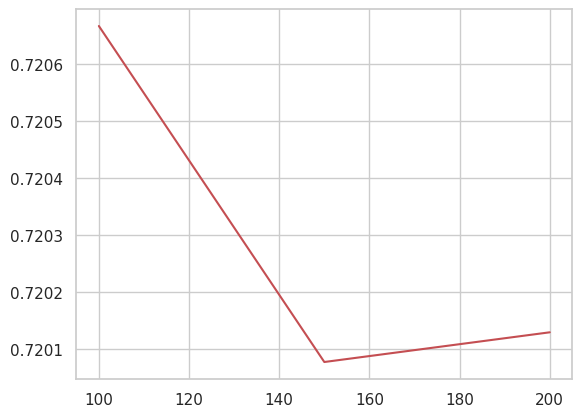

In [45]:
plt.plot(factor_values, mae_values, 'r-')
plt.show()

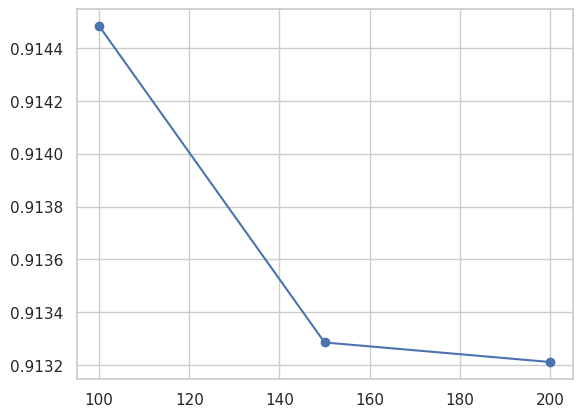

In [46]:
plt.plot(factor_values, rmse_values, 'bo-')
plt.show()

# Mis gráficos


In [48]:
# Factores
factor_values = [300, 350, 450] # tres menores
mae_values = []
rmse_values = []

for f in factor_values:
  svd.train(factors=f, maxiter=100, lr=0.01, lamb=0.1)

  predlist, mae, rmse = svd.test(input_file='u2.test',
                                 dlmchar=b'\t',
                                 header=False,
                                 usercol=0,
                                 itemcol=1,
                                 ratingcol=2)

  mae_values.append(mae)
  rmse_values.append(rmse)

print(mae_values)
print(rmse_values)

[0.720294239169141, 0.7204931891334705, 0.7201038900595402]
[0.9135992799256892, 0.9136200358024186, 0.9129530236762445]


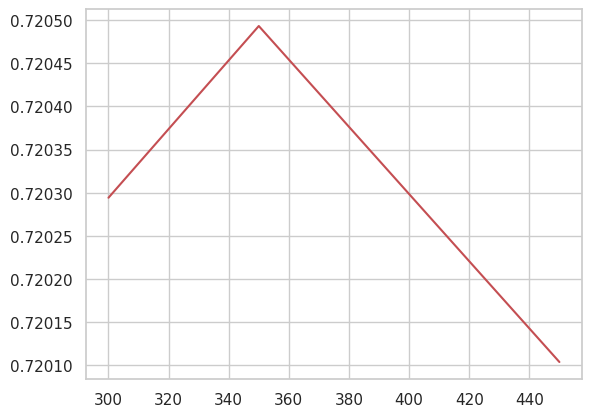

In [49]:
plt.plot(factor_values, mae_values, 'r-')
plt.show()

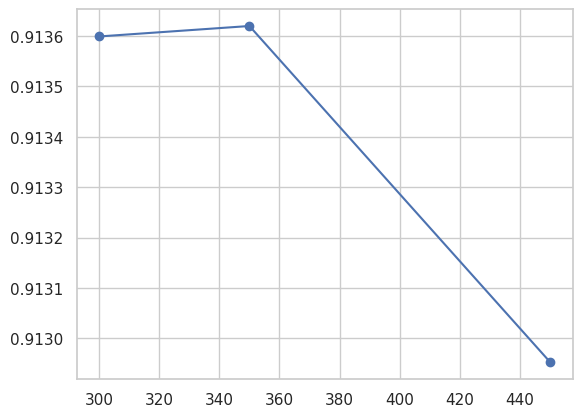

In [50]:
plt.plot(factor_values, rmse_values, 'bo-')
plt.show()

In [59]:
# interacciones
interacciones = [100, 150, 400] # tres mejores
mae_values = []
rmse_values = [] # para almacenar valores de NDCG

for i in interacciones:
  svd.train(factors=100, maxiter=i, lr=0.01, lamb=0.1)

  predlist, mae, rmse = svd.test(input_file='u2.test',
                                 dlmchar=b'\t',
                                 header=False,
                                 usercol=0,
                                 itemcol=1,
                                 ratingcol=2)

  mae_values.append(mae)
  rmse_values.append(rmse)

print(mae_values)
print(rmse_values)

[0.7208832744961632, 0.7210100540793938, 0.7215983873996588]
[0.91490658870758, 0.9145601580132555, 0.9157413798733582]


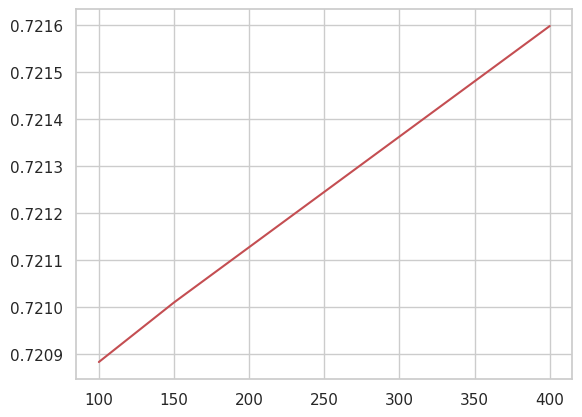

In [60]:
plt.plot(interacciones, mae_values, 'r-')
plt.show()

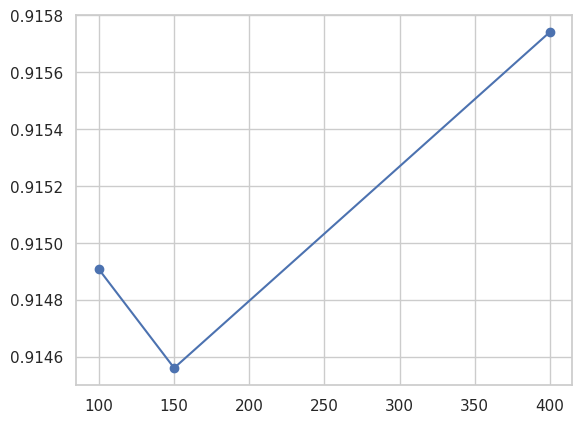

In [61]:
plt.plot(interacciones, rmse_values, 'bo-')
plt.show()

In [62]:
# LR
learning_rate = [0.01, 0.02, 0.03] # tres mejores
mae_values = []
rmse_values = [] # para almacenar valores de NDCG

for l in learning_rate:
  svd.train(factors=100, maxiter=100, lr=l, lamb=0.1)

  predlist, mae, rmse = svd.test(input_file='u2.test',
                                 dlmchar=b'\t',
                                 header=False,
                                 usercol=0,
                                 itemcol=1,
                                 ratingcol=2)

  mae_values.append(mae)
  rmse_values.append(rmse)

print(mae_values)
print(rmse_values)

[0.7213325299204381, 0.7243792133159342, 0.7286060850679588]
[0.9146354332741167, 0.9181845149939004, 0.922396046905815]


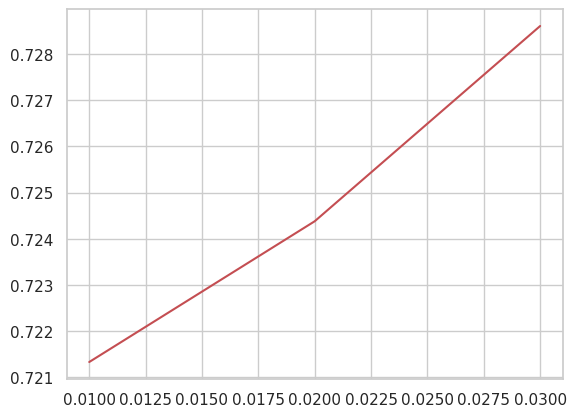

In [63]:
plt.plot(learning_rate, mae_values, 'r-')
plt.show()

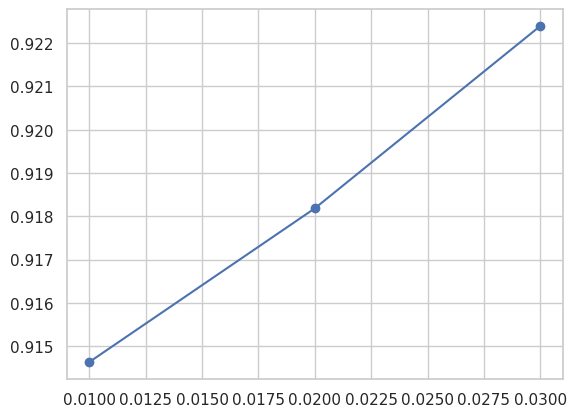

In [64]:
plt.plot(learning_rate, rmse_values, 'bo-')
plt.show()

**Paso 9 (6 ptos):** Pruebe con otros valores y/o parámetros (mínimo 3 combinaciones. Se recomienda elegir entre las combinaciones del paso 7):

*USÉ IA PARA LOS ERRORES* https://chatgpt.com/share/69bdc0ba-8f78-8010-82ef-3014485c12eb

# Respuesta

La respuesta es rara. Al poner los tres mejores factores el resultado primero empeora, pero luego mejora claramente.

Al probar con las interacciones siempre empeora, eso es menos contraintuitivo que el anterior (aunque con 150 mejora un porquito el rmse).

Al probar el learning rate es consistente que empeora con los tres valores propuestos.

Entonces, el LR es claro que entre mayor el número el resultado empeora, pero en los otros la métrica es fina.